In [1]:
"""
    Importeer libraries
    """
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from math import sqrt, ceil
from scipy.stats import linregress    
import libraries as lib
import math 
    

In [2]:
# Set Lees GPS data met hoogte-data in
"""
    Maak dataframe  met hoogte data.

    Parameters:
        file_path: directory van het bestand met hoogteprofiel

    Returns:
        DataFrame: Het dataframe met hoogte data.
    """

file_path = "/Users\qvled\OneDrive - HvA\Clean_Mobility_Files\H2A\Data voor hoogteprofiel.txt"

# Read GPS data
hoogte_df = lib.lees_gps_data(file_path)

# Print the resulting DataFrame
hoogte_df


,timestamp,latitude,lat_direction,longitude,lon_direction,hoogte,speed_m/s
0,063448.30,43.771393,N,-0.042098,W,99.5,0.038583
1,063448.40,43.771393,N,-0.042098,W,99.5,0.026237
2,063448.50,43.771393,N,-0.042098,W,99.4,0.035497
3,063448.60,43.771393,N,-0.042098,W,99.5,0.073051
4,063448.70,43.771393,N,-0.042098,W,99.4,0.064820
...,...,...,...,...,...,...,...
46568,None,43.771202,N,-0.041941,W,96.0,NaN
46569,None,43.771202,N,-0.041941,W,96.0,NaN
46570,None,43.771202,N,-0.041941,W,96.1,NaN
46571,None,43.771202,N,-0.041941,W,96.1,NaN


In [3]:
#Filter vanaf het moment dat de auto de baan opgaat en wanneer die er weer afgaat.
"""
    Filter de data handmatig vanaf een opgegeven startrij tot een opgegeven eindrij.

    Parameters:
        data_file_motordriver (DataFrame): Het originele DataFrame.
        start_row (int): Het indexnummer van de rij waarmee het filteren moet beginnen.
        end_row (int): Het indexnummer van de rij waarmee het filteren moet eindigen.

    Returns:
        DataFrame: Het gefilterde DataFrame vanaf start_row tot end_row.
    """
# Definieer de coördinaten voor het start- en eindpunt
start_lon = -0.0446
start_lat = 0.00095 + 4.3771e1
end_lon = -0.039925
end_lat = 0.000300 + 4.3771e1

# Veronderstel dat 'df' je DataFrame is met de relevante data
filtered_hoogte_df = lib.filter_track_data(hoogte_df, start_lon, start_lat, end_lon, end_lat)

# Print het gefilterde DataFrame om te controleren
filtered_hoogte_df
#43.767914, -0.035855

,timestamp,latitude,lat_direction,longitude,lon_direction,hoogte,speed_m/s
22340,071203.60,43.771951,N,-0.044597,W,102.0,5.597156
22341,071203.70,43.771954,N,-0.044603,W,102.0,5.624421
22342,071203.80,43.771955,N,-0.044609,W,102.0,5.633167
22343,071203.90,43.771958,N,-0.044616,W,102.0,5.650143
22344,071204.00,43.771960,N,-0.044622,W,102.0,5.655288
...,...,...,...,...,...,...,...
42943,074720.40,43.771037,N,-0.040149,W,98.1,8.270209
42944,074720.50,43.771032,N,-0.040142,W,98.1,8.298503
42945,074720.60,43.771027,N,-0.040135,W,98.1,8.276382
42946,074720.70,43.771022,N,-0.040127,W,98.1,8.287700


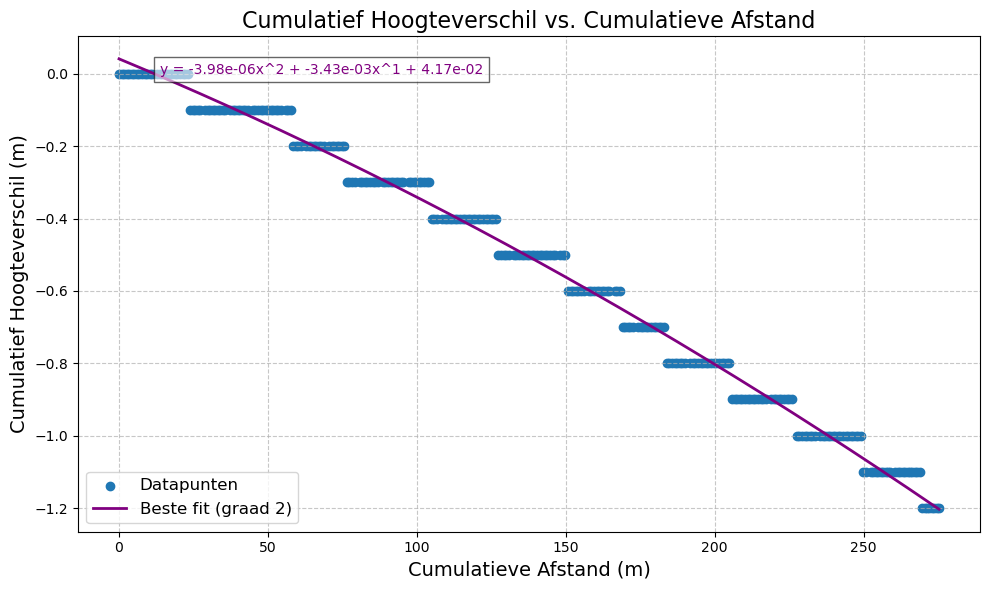

y = -3.98e-06x^2 + -3.43e-03x^1 + 4.17e-02


,timestamp,latitude,lat_direction,longitude,lon_direction,hoogte,afstand,hoogteverschil,cumulatieve_afstand,cumulatief_hoogteverschil
25407,071724.80,43.772431,N,-0.042159,W,99.0,0.000000,0.0,0.000000,0.0
25408,071724.90,43.772426,N,-0.042151,W,99.0,0.859701,0.0,0.859701,0.0
25409,071725.00,43.772421,N,-0.042143,W,99.0,0.849538,0.0,1.709239,0.0
25410,071725.10,43.772416,N,-0.042135,W,99.0,0.859701,0.0,2.568940,0.0
25411,071725.20,43.772411,N,-0.042127,W,99.0,0.861780,0.0,3.430720,0.0
...,...,...,...,...,...,...,...,...,...,...
25702,071756.50,43.770697,N,-0.039776,W,97.8,0.820372,0.0,272.130751,-1.2
25703,071756.60,43.770690,N,-0.039771,W,97.8,0.808054,0.0,272.938805,-1.2
25704,071756.70,43.770684,N,-0.039767,W,97.8,0.802159,0.0,273.740964,-1.2
25705,071756.80,43.770677,N,-0.039763,W,97.8,0.796446,0.0,274.537410,-1.2


In [5]:
start_index_r = 25407
eind_index_r = 25706

hoogte_met_afstand_df_r = lib.bereken_afstand_en_hoogteverschil(filtered_hoogte_df, start_index_r, eind_index_r)

polynomial_r = lib.plot_hoogte_vs_afstand_met_fit(hoogte_met_afstand_df_r, 2)

hoogte_met_afstand_df_r

In [7]:
"""
    Laadt motordriver-data in, selecteert een subset van rijen, corrigeert GPS-coördinaten
    en voegt snelheden in m/s toe.

    Parameters:
    directory (str): Pad naar de directory met het databestand.
    file_motordriver (str): Naam van het motordriver-databestand.
    start_row (int): Startindex van de te selecteren rijen (inclusief).
    end_row (int): Eindindex van de te selecteren rijen (inclusief).

    Returns:
    pd.DataFrame: Geprocessed DataFrame met geselecteerde rijen, gecorrigeerde GPS-coördinaten
                  en snelheden in m/s.
    """

directory = "/Users\qvled\OneDrive - HvA\Logfiles\H2A/2023/Nogaro/20230525_h2a_poging1/0002/"
file_motordriver = "5.csv"
start_row = 223257
end_row = 479444

filtered_motordriver = lib.verwerk_motordriver_data(directory, file_motordriver, start_row, end_row)
filtered_motordriver

"""
    Maak apparte dataframes van elke ronde.
        """


#Maken df's per ronde motordriver
begin_eind_paren2 = [
    (0, 26251), 
    (26251, 49486), 
    (49486, 74393), 
    (74393, 100200),
    (100200, 124732), 
    (124732, 149852), 
    (149852, 174488), 
    (174488, 200208),
    (200208, 226012), 
    (226012, 255494)
]

# Maak een lege lijst om de rondes-dataframes op te slaan
rondes = []

# Loop door elke (begin, eind) paar en maak een DataFrame subset
for i, (begin, eind) in enumerate(begin_eind_paren2):
    df_segment = filtered_motordriver.iloc[begin:eind]
    rondes.append(df_segment)

# Je kunt nu elke ronde benaderen als rondes[0], rondes[1], etc.
df_ronde1 = rondes[0]
df_ronde2 = rondes[1]
df_ronde3 = rondes[2]
df_ronde4 = rondes[3]
df_ronde5 = rondes[4]
df_ronde6 = rondes[5]
df_ronde7 = rondes[6]
df_ronde8 = rondes[7]
df_ronde9 = rondes[8]
df_ronde10 = rondes[9]

# Print het resultaat voor een ronde om te controleren
df_ronde7


,Datalogger port,"Dataloggertijd, in s",Format header (>03|04),Tijd sinds laatste herstart motordriver (s),Spanning over de motor (V),Stroom door de motor (A),Vermogen geleverd aan de motor (W),Energie geleverd aan de motor sinds reset (J),Spanning aan de ingang van motordriver (V),Stroom door de ingang van motordriver (A),...,"Toestand cruise control2-knop (aan=1, uit=0)",Tijdstip laatste verandering cruise control2-knop,"GPS longitude, in graden","GPS latitude, in graden",GPS direction,"GPS speed, in km/h","GPS time, in seconden sinds het begin van de huidige GPS-week",Checksum,"Wielsnelheid, in m/s","GPS speed, in m/s"
373109,5,5837.5808,03|04,2195.9629,21.155,7.969,180.1,114188,27.357,6.742,...,0,2131.384,-0.040835,43.770947,322.7,26.3,80035.0,NaN,7.287778,7.305556
373110,5,5837.5896,03|04,2195.9717,20.881,7.951,176.7,114189,27.356,6.746,...,0,2131.384,-0.040835,43.770947,322.8,26.3,80035.0,NaN,7.443889,7.305556
373111,5,5837.5984,03|04,2195.9807,20.706,7.930,175.4,114191,27.356,6.744,...,0,2131.384,-0.040835,43.770947,322.8,26.3,80035.0,NaN,7.293056,7.305556
373112,5,5837.6073,03|04,2195.9895,20.995,8.003,179.2,114193,27.355,6.746,...,0,2131.384,-0.040835,43.770947,322.8,26.3,80035.0,NaN,7.385833,7.305556
373113,5,5837.6161,03|04,2195.9983,20.981,8.040,180.1,114194,27.354,6.756,...,0,2131.384,-0.040835,43.770947,322.8,26.3,80035.0,NaN,7.293333,7.305556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397740,5,6054.6428,03|04,2412.9873,20.286,8.068,175.6,132123,27.457,6.436,...,0,2402.446,-0.040793,43.771008,324.7,24.6,80411.8,NaN,6.807778,6.833333
397741,5,6054.6516,03|04,2412.9961,20.145,7.973,172.4,132125,27.456,6.425,...,0,2402.446,-0.040793,43.771008,324.7,24.6,80411.8,NaN,6.998611,6.833333
397742,5,6054.6605,03|04,2413.0049,20.052,8.024,173.3,132126,27.455,6.431,...,0,2402.446,-0.040793,43.771008,324.7,24.6,80411.8,NaN,6.810556,6.833333
397743,5,6054.6694,03|04,2413.0139,19.878,7.993,171.0,132128,27.454,6.438,...,0,2402.446,-0.040803,43.771018,324.7,24.8,80411.8,NaN,7.021667,6.888889


In [ ]:
"""
    Maakt een scatterplot met Plotly waarbij bij hoveren de rij-index en de x- en y-waarden worden weergegeven,
    en voegt optioneel handmatig opgegeven punten toe op specifieke coördinaten.

    Parameters:
    df (pd.DataFrame): De DataFrame met de te plotten data.
    x_col (str): De naam van de kolom voor de x-as.
    y_col (str): De naam van de kolom voor de y-as.
    label (str): Het label voor de dataset in de plot.
    custom_points (list of tuples, optional): Lijst met tuples, elk met (x, y) coördinaten voor de toe te voegen punten. Standaard is None.

    Returns:
    None
    """

custom_points = [(-0.043588, 43.772817), # filtered_motordriver.loc[388561]
                 (-0.039707, 43.770703), # filtered_motordriver.loc[394866]
                 (-0.045478, 43.773305),
                 (-0.043947, 43.773997),
                 (-0.043483, 43.77286),
                 (-0.039763, 43.77075),
                 (-0.042835, 43.77273),
                 (-0.04269667, 43.7727),
                 (-0.04024833, 43.77037),
                 (-0.04216167, 43.77246)]

lib.plot_scatter_with_custom_points(filtered_hoogte_df, 'longitude', 'latitude', 'Joehoe', custom_points)

"""
    Maakt een interactieve scatterplot van GPS-coördinaten met kleuren die afhankelijk zijn van het geleverde vermogen.
    Optioneel kunnen aangepaste punten worden toegevoegd.

    Parameters:
    df (pd.DataFrame): DataFrame met de kolommen 'GPS longitude, in graden', 'GPS latitude, in graden' en 'Vermogen geleverd aan de motor (W)'.
    custom_points (list of tuples, optional): Lijst met tuples met (longitude, latitude) coördinaten voor extra punten. Standaard is None.

    Returns:
    Geel = geen vermogen
    Blauw = Wel vermogen
    Rood = Zelf ingevoerde punten
    """

# Aanroepen van de functie met aangepaste punten
lib.plot_gps_power(df_ronde3, custom_points=custom_points)




In [8]:
df_meetstuk_r = df_ronde3.loc[290888:295371]

df_meetstuk_r

,Datalogger port,"Dataloggertijd, in s",Format header (>03|04),Tijd sinds laatste herstart motordriver (s),Spanning over de motor (V),Stroom door de motor (A),Vermogen geleverd aan de motor (W),Energie geleverd aan de motor sinds reset (J),Spanning aan de ingang van motordriver (V),Stroom door de ingang van motordriver (A),...,"Toestand cruise control2-knop (aan=1, uit=0)",Tijdstip laatste verandering cruise control2-knop,"GPS longitude, in graden","GPS latitude, in graden",GPS direction,"GPS speed, in km/h","GPS time, in seconden sinds het begin van de huidige GPS-week",Checksum,"Wielsnelheid, in m/s","GPS speed, in m/s"
290888,5,5120.8308,03|04,1479.3368,0.019,-0.059,-0.0,58328,29.286,-0.004,...,1,1452.599,-0.042157,43.772517,132.9,26.1,74838.0,NaN,7.381111,7.250000
290889,5,5120.8394,03|04,1479.3456,0.020,-0.060,-0.0,58328,29.287,-0.008,...,1,1452.599,-0.042142,43.772507,132.9,26.3,74838.2,NaN,7.267500,7.305556
290890,5,5120.8481,03|04,1479.3542,0.020,-0.060,-0.0,58328,29.287,-0.006,...,1,1452.599,-0.042142,43.772507,132.7,26.3,74838.2,NaN,7.416389,7.305556
290891,5,5120.8568,03|04,1479.3628,0.020,-0.059,-0.0,58328,29.288,-0.001,...,1,1452.599,-0.042142,43.772507,132.7,26.3,74838.2,NaN,7.258611,7.305556
290892,5,5120.8654,03|04,1479.3716,0.020,-0.057,-0.0,58328,29.288,-0.001,...,1,1452.599,-0.042142,43.772507,132.7,26.3,74838.2,NaN,7.418056,7.305556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295367,5,5159.5898,03|04,1518.0892,0.019,-0.070,-0.0,58328,30.592,-0.015,...,1,1452.599,-0.039775,43.770758,134.2,24.1,74916.8,NaN,6.642222,6.694444
295368,5,5159.5985,03|04,1518.0978,0.020,-0.069,-0.0,58328,30.593,-0.013,...,1,1452.599,-0.039775,43.770758,134.2,24.1,74916.8,NaN,6.786667,6.694444
295369,5,5159.6071,03|04,1518.1066,0.021,-0.068,-0.0,58328,30.593,-0.012,...,1,1452.599,-0.039775,43.770758,134.2,24.1,74916.8,NaN,6.587778,6.694444
295370,5,5159.6158,03|04,1518.1152,0.021,-0.066,-0.0,58328,30.594,-0.010,...,1,1452.599,-0.039775,43.770758,134.2,24.1,74916.8,NaN,6.792500,6.694444


In [9]:
# Print de eerste rij
print("Eerste rij:")
df_meetstuk_r.head(1)

Eerste rij:


,Datalogger port,"Dataloggertijd, in s",Format header (>03|04),Tijd sinds laatste herstart motordriver (s),Spanning over de motor (V),Stroom door de motor (A),Vermogen geleverd aan de motor (W),Energie geleverd aan de motor sinds reset (J),Spanning aan de ingang van motordriver (V),Stroom door de ingang van motordriver (A),...,"Toestand cruise control2-knop (aan=1, uit=0)",Tijdstip laatste verandering cruise control2-knop,"GPS longitude, in graden","GPS latitude, in graden",GPS direction,"GPS speed, in km/h","GPS time, in seconden sinds het begin van de huidige GPS-week",Checksum,"Wielsnelheid, in m/s","GPS speed, in m/s"
290888,5,5120.8308,03|04,1479.3368,0.019,-0.059,-0.0,58328,29.286,-0.004,...,1,1452.599,-0.042157,43.772517,132.9,26.1,74838.0,NaN,7.381111,7.25


In [10]:
# Print de laatste rij
print("\nLaatste rij:")
df_meetstuk_r.tail(1)


Laatste rij:


,Datalogger port,"Dataloggertijd, in s",Format header (>03|04),Tijd sinds laatste herstart motordriver (s),Spanning over de motor (V),Stroom door de motor (A),Vermogen geleverd aan de motor (W),Energie geleverd aan de motor sinds reset (J),Spanning aan de ingang van motordriver (V),Stroom door de ingang van motordriver (A),...,"Toestand cruise control2-knop (aan=1, uit=0)",Tijdstip laatste verandering cruise control2-knop,"GPS longitude, in graden","GPS latitude, in graden",GPS direction,"GPS speed, in km/h","GPS time, in seconden sinds het begin van de huidige GPS-week",Checksum,"Wielsnelheid, in m/s","GPS speed, in m/s"
295371,5,5159.6245,03|04,1518.1238,0.02,-0.068,-0.0,58328,30.595,-0.011,...,1,1452.599,-0.039775,43.770758,134.2,24.1,74916.8,NaN,6.604444,6.694444


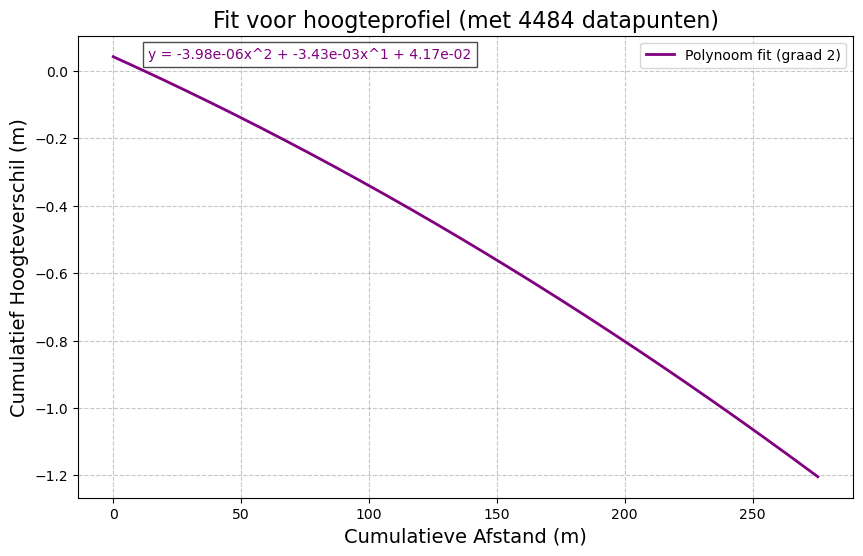

,hoogteverschil (m),delta h (m)
0,0.041686,0.000000
1,0.041475,-0.000210
2,0.041265,-0.000211
3,0.041054,-0.000211
4,0.040844,-0.000211
...,...,...
4479,-1.202601,-0.000345
4480,-1.202947,-0.000345
4481,-1.203292,-0.000345
4482,-1.203637,-0.000345


In [11]:
"""
    Voert een polynoomfit uit op het hoogteprofiel, plot de fit en berekent het hoogteverschil.

    Parameters:
    dataframe (pd.DataFrame): DataFrame met de kolommen 'cumulatieve_afstand' en 'cumulatief_hoogteverschil'.
    polynoom_graad (int): De graad van de polynoom die aan de data wordt aangepast.
    x_fit_start (float): De startwaarde voor de x-as bij het genereren van de fit.
    x_fit_end (float): De eindwaarde voor de x-as bij het genereren van de fit.
    num_points (int): Het aantal punten voor de x-as bij het genereren van de fit.

    Returns:
    pd.DataFrame: DataFrame met de berekende hoogteverschillen en hun verschillen.
    """
# Aanroepen van de functie

df_hr = lib.analyseer_hoogteprofiel(hoogte_met_afstand_df_r, polynoom_graad=2, x_fit_start=0, x_fit_end=275.47, num_points=4484)

# Bekijken van de eerste paar rijen van het resultaat
df_hr




In [ ]:
import numpy as np
import pandas as pd

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance (in meters) between two points
    on the Earth specified by latitude and longitude.
    """
    R = 6371000  # Earth's radius in meters
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def bereken_energie(df):
    """
    Bereken de potentiële en kinetische energie op basis van hoogte-, snelheid- en GPS-afstandsgegevens.

    Parameters:
    df (pd.DataFrame): DataFrame met de kolommen 'hoogteverschil (m)', 'Wielsnelheid, in m/s',
                       'GPS speed, in m/s', 'GPS latitude, in graden', 'GPS longitude, in graden'.

    Returns:
    pd.DataFrame: DataFrame met berekende energieën en weerstand.
    """
    g = 9.81  # Zwaartekrachtversnelling in m/s²
    massa = 90  # Massa van het object in kilogram

    # Drop rows with missing latitude or longitude
    df = df.dropna(subset=['GPS latitude, in graden', 'GPS longitude, in graden']).reset_index(drop=True)

    # Calculate GPS distances between consecutive rows
    df['GPS afstand (m)'] = haversine(
        df['GPS latitude, in graden'].shift(1),
        df['GPS longitude, in graden'].shift(1),
        df['GPS latitude, in graden'],
        df['GPS longitude, in graden']
    )

    # Replace NaN in the first row (since shift(1) causes it) with 0
    df['GPS afstand (m)'] = df['GPS afstand (m)'].fillna(0)

    # Cumulative distance
    df['Afgelegde afstand (m)'] = df['GPS afstand (m)'].cumsum()
    df['Afgelegde afstand wiel (m)'] = df['Afgelegde afstand sinds laatste herstart motordriver (m)'] - df['Afgelegde afstand sinds laatste herstart motordriver (m)'].iloc[0]

    # Energies calculations
    initiele_hoogte = df['hoogteverschil (m)'].iloc[0]  # Starting height
    df['Potentiële Energie (J)'] = massa * g * (df['hoogteverschil (m)'] - initiele_hoogte).abs()
    df['Delta Potentiële Energie (J)'] = df['Potentiële Energie (J)'].diff().fillna(0)
    df['Cumulatieve Omzetting naar Kinetische Energie (J)'] = df['Delta Potentiële Energie (J)'].cumsum()

    # Initial kinetic energy based on the first row's speed
    begin_snelheid = df['GPS speed, in m/s'].iloc[0]
    begin_snelheid_wiel = df['Wielsnelheid, in m/s'].iloc[0]
    initiele_kinetische_energie = 0.5 * massa * (begin_snelheid_wiel ** 2)
    initiele_kinetische_energie_wiel = 0.5 * massa * (begin_snelheid_wiel ** 2)

    #berekent met gps snelheid
    df['Theoretische Kinetische Energie (J)'] = initiele_kinetische_energie - df['Cumulatieve Omzetting naar Kinetische Energie (J)']

    df['Totale theoretische energie (J)'] = df['Theoretische Kinetische Energie (J)'] + df['Potentiële Energie (J)']

    #berekent met wielsnelheid
    df['Theoretische Kinetische Energie wiel (J)'] = initiele_kinetische_energie_wiel - df['Cumulatieve Omzetting naar Kinetische Energie (J)']

    df['Totale theoretische energie wiel (J)'] = df['Theoretische Kinetische Energie wiel (J)'] + df['Potentiële Energie (J)']

    # Measured kinetic energy based on GPS speed
    df['Gemeten kinetische energie (GPS) (J)'] = 0.5 * massa * (df['GPS speed, in m/s'] ** 2)
    df['Totale gemeten energie (GPS) (J)'] = df['Gemeten kinetische energie (GPS) (J)'] + df['Potentiële Energie (J)']

    # Resistance calculation GPS snelheid
    df['Energie verschil berekend en gemeten (J)'] = df['Totale theoretische energie (J)'] - df['Totale gemeten energie (GPS) (J)']
    df['delta energie berekend en gemeten (J)'] = df['Energie verschil berekend en gemeten (J)'].diff().fillna(0)
    df['delta afstand (m)'] = df['Afgelegde afstand (m)'].diff()
    df['Weerstand met GPS Snelheid (N)'] = df['delta energie berekend en gemeten (J)'] / df['delta afstand (m)']

    # Resistance calculation wielsnelheid
    df['Energie verschil berekend en gemeten wiel (J)'] = df['Totale theoretische energie wiel (J)'] - df['Totale theoretische energie wiel (J)']

    df['delta energie berekend en gemeten wiel (J)'] = df['Energie verschil berekend en gemeten wiel (J)'].diff().fillna(0) 

    df['delta energie berekend en gemeten wiel goed (J)'] = df['delta energie berekend en gemeten wiel (J)'] *-1
    
    df['delta afstand wiel (m)'] = df['Afgelegde afstand wiel (m)'].diff()

    df['Weerstand met wielsnelheid (N)'] = df['delta energie berekend en gemeten wiel (J)'] / df['delta afstand wiel (m)']

    return df


In [ ]:


# Controleer of beide DataFrames dezelfde lengte hebben
# Dit is essentieel om ervoor te zorgen dat de rijen correct op elkaar worden afgestemd bij het samenvoegen.
if len(df_meetstuk_r) != len(df_hr):
    raise ValueError("De DataFrames hebben niet dezelfde lengte en kunnen niet direct worden samengevoegd.")

# Stap 1: Identificeer de kolommen die al bestaan in df_meetstuk
# Dit wordt gedaan door de intersectie te nemen van de kolommen van beide DataFrames.
bestaande_kolommen = df_meetstuk_r.columns.intersection(df_h.columns)

# Stap 2: Verwijder de bestaande kolommen uit df_h
# Hierdoor blijven alleen de kolommen over die nog niet in df_meetstuk aanwezig zijn.
df_h_uniek = df_hr.drop(columns=bestaande_kolommen)

# Stap 3: Voeg de DataFrames samen
# Beide DataFrames worden eerst gereset naar een standaard numerieke index om ervoor te zorgen dat de rijen correct worden uitgelijnd.
# Vervolgens worden ze
# kolomgewijs samengevoegd met behulp van pd.concat.
df_meetstuk_r = pd.concat([df_meetstuk_r.reset_index(drop=True), df_h_uniek.reset_index(drop=True)], axis=1)

# Toon het bijgewerkte DataFrame
# Dit geeft een overzicht van df_meetstuk met de toegevoegde kolommen uit df_h.
df_meetstuk_r


In [ ]:

# Bereken de energieën
df_energie_r = bereken_energie(df_meetstuk_r)

# Controleer of beide DataFrames dezelfde lengte hebben
if len(df_meetstuk_r) != len(df_energie_r):
    raise ValueError("De DataFrames hebben niet dezelfde lengte en kunnen niet direct worden samengevoegd.")

# Stap 1: Identificeer de kolommen die al bestaan in df_meetstuk
bestaande_kolommen = df_meetstuk_r.columns.intersection(df_energie_r.columns)

# Stap 2: Verwijder de bestaande kolommen uit df_energie
df_energie_uniek_r = df_energie_r.drop(columns=bestaande_kolommen)

# Stap 3: Voeg de DataFrames samen
df_meetstuk_r = pd.concat([df_meetstuk_r.reset_index(drop=True), df_energie_uniek_r.reset_index(drop=True)], axis=1)

df_meetstuk_r = lib.process_angular_data(df_meetstuk_r, direction_col='GPS direction', reference_direction=90.0)

# Toon het bijgewerkte DataFrame
df_meetstuk_r



In [12]:
import plotly.graph_objects as go

# Function to create scatter plots with an optional bar chart
def create_scatter_and_bar_plot(df, title, bar_column, bar_title):
    """
    Create scatter plots and bar plots for a given DataFrame.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        title (str): The title of the scatter plot.
        marker_symbol (str): Marker symbol for the scatter plot.
        bar_column (str): Column to plot as bar chart.
        bar_title (str): Title of the bar chart.
    """
    fig = go.Figure()

    # Scatter Plot
    fig.add_trace(go.Scatter(
        x=df['Dataloggertijd, in s'],
        y=df['Weerstand met wielsnelheid (N)'],
        mode='markers',
        marker=dict(
            size=10,
            color=df['GPS speed, in km/h'],  # Color based on GPS speed
            colorscale='Viridis',
            colorbar=dict(title="Snelheid (km/h)")
        ),
        text=df['GPS speed, in km/h'],  # Tooltip
        hoverinfo='x+y+text',
        name='Weerstand vs Tijd'
    ))

    # Bar Chart
    fig.add_trace(go.Bar(
        x=df['Dataloggertijd, in s'],
        y=df[bar_column],
        name=bar_title,
        opacity=0.6,
        marker_color='rgba(200, 50, 100, 0.6)'  # Semi-transparent red bars
    ))

    # Layout settings
    fig.update_layout(
        title=title,
        xaxis_title='Dataloggertijd (s)',
        yaxis_title='Weerstand kracht (N)',
        yaxis=dict(range=[-30, 10]),
        barmode='overlay',  # Combine bar and scatter in one plot
        legend=dict(x=0.8, y=1.0),
        template="plotly_white"
    )

    fig.show()

In [ ]:
create_scatter_and_bar_plot(df_meetstuk_r,
                            title='Weerstand rechte stuk rechtsonder ronde 3',
                            bar_column='Weerstand met wielsnelheid (N)',
                            bar_title='Weerstand als staafdiagram')